In [ ]:
# Supprime les dossiers et fichiers existant
!rm -rf /content/*

## ***1. Installation de MMPose***

On installe MMPose sans GPU puis on applique un patch supprimant tout les modèles pouvant poser problème lors de l'installation sans GPU.

---

In [ ]:
# Toujours utiliser %pip dans Colab
%pip uninstall  -y mmpose mmcv mmcv-lite mmdet >/dev/null 2>&1

# mmcv-lite en premier, PAS de C++ ops
%pip install -q mmcv-lite==2.0.1

# mmdet sans deps pour ne PAS tirer "mmcv" full
%pip install -q --no-deps mmdet==3.3.0

# Récupère le code MMPose v1.3.2 et PATCH pour éviter l'import des têtes "transformer"
import os, shutil, subprocess, textwrap, sys
repo = "/content/mmpose_cpu_patch"
shutil.rmtree(repo, ignore_errors=True)
subprocess.check_call(["git","clone","--depth","1","--branch","v1.3.2",
                       "https://github.com/open-mmlab/mmpose.git", repo])

# 1) Retirer 'chumpy' (inutile en 2D et problématique en Py3.12)
for meta in ("setup.cfg","pyproject.toml"):
    p = os.path.join(repo, meta)
    if os.path.exists(p):
        s = open(p,"r",encoding="utf-8").read().replace("chumpy","")
        open(p,"w",encoding="utf-8").write(s)

# 2) Désactiver totalement les "transformer_heads" (EDPose)
heads_init = os.path.join(repo, "mmpose/models/heads/__init__.py")
if os.path.exists(heads_init):
    s = open(heads_init,"r",encoding="utf-8").read()
    # supprime toute ligne qui importe transformer_heads
    s = "\n".join([ln for ln in s.splitlines() if "transformer_heads" not in ln])
    open(heads_init,"w",encoding="utf-8").write(s)

# 3) Supprime le dossier des transformer_heads pour être 100% safe
tf_dir = os.path.join(repo, "mmpose/models/heads/transformer_heads")
shutil.rmtree(tf_dir, ignore_errors=True)

# Installe le paquet patché (non-editable pour éviter les soucis de chemins)
%pip install -q /content/mmpose_cpu_patch

# Sanity checks
import importlib.util, pkgutil, mmcv, mmpose
print("mmcv version:", getattr(mmcv, "__version__", "N/A"))
print("mmcv._ext chargeable ?",
      end=" ")
try:
    import mmcv._ext as _ext
    print("Oui (peu probable en CPU).")
except Exception as e:
    print("Non (c'est attendu en CPU).")
print("mmpose file:", getattr(mmpose, "__file__", None))
print("mmpose.apis visible ?",
      importlib.util.find_spec("mmpose.apis") is not None)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 715.0/715.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
mmcv version: 2.0.1
mmcv._ext chargeable ? Non (c'est attendu en CPU).
mmpose file: /usr/local/lib/python3.12/dist-packages/mmpose/__init__.py
mmpose.apis visible ? True


***PATCH :***

In [ ]:
from pathlib import Path

# 1) Supprime les imports/mentions d'EDPoseHead & transformer_heads dans heads/__init__.py
p_heads = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py')
txt = p_heads.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_heads.write_text(txt2, encoding='utf-8')

# 2) Supprime les mentions d'EDPoseHead & transformer_heads dans models/__init__.py
p_models = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py')
txt = p_models.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_models.write_text(txt2, encoding='utf-8')

print("Patched:", p_heads, "and", p_models)

# 3) Purge le cache d'import mmpose pour recharger les fichiers patchés
import sys
for k in list(sys.modules):
    if k.startswith('mmpose'):
        del sys.modules[k]
print("Import cache purged for mmpose.*")


Patched: /usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py and /usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py
Import cache purged for mmpose.*


---
## ***2. Configuration de HRNet***

On récupère via GitHub tout les fichiers de poids (.pth) et de configuration (.py) nécessaire au bon fonctionnement de HRNet.

---

In [ ]:
import os, urllib.request

os.makedirs("/content/checkpoints", exist_ok=True)
os.makedirs("/content/configs", exist_ok=True)

# Checkpoint HRNet (heatmap, compatible CPU)
ckpt = "/content/checkpoints/hrnet_w48_coco_256x192.pth"
if not os.path.exists(ckpt):
    urllib.request.urlretrieve(
        "https://download.openmmlab.com/mmpose/top_down/hrnet/hrnet_w48_coco_256x192-b9e0b3ab_20200708.pth",
        ckpt
    )

# Config (on prend celle de MMPose 1.3.2)
cfg_url = "https://raw.githubusercontent.com/open-mmlab/mmpose/v1.3.2/configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_hrnet-w48_8xb32-210e_coco-256x192.py"
CFG = "/content/configs/td-hm_hrnet-w48_8xb32-210e_coco-256x192.py"
if not os.path.exists(CFG):
    urllib.request.urlretrieve(cfg_url, CFG)

print("Config et checkpoint prêts.")


Config et checkpoint prêts.


---

On vérifie que tout s'est bien installé puis on initialise le modèle :

---



In [ ]:
import os, subprocess

# 1) S'assurer d'avoir une arborescence "configs" complète (repo)
repo_cfg = "/content/mmpose_cpu_patch/configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_hrnet-w48_8xb32-210e_coco-256x192.py"
fallback_repo = "/content/mmpose_src/configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_hrnet-w48_8xb32-210e_coco-256x192.py"

if not os.path.exists(repo_cfg) and not os.path.exists(fallback_repo):
    # (re)cloner un repo propre (léger) avec les configs
    subprocess.check_call(["git","clone","--depth","1","--branch","v1.3.2",
                           "https://github.com/open-mmlab/mmpose.git","/content/mmpose_src"])

# 2) Choisir le chemin final de la config (dans un repo, pas dans /content/configs)
if os.path.exists(repo_cfg):
    CFG = repo_cfg
elif os.path.exists(fallback_repo):
    CFG = fallback_repo
else:
    # dernier recours : HRNet W48 ancienne arborescence
    alt_old = "/content/mmpose_src/configs/body_2d_keypoint/topdown_heatmap/coco/hrnet_w48_coco_256x192.py"
    assert os.path.exists(alt_old), "Impossible de localiser une config HRNet dans le repo."
    CFG = alt_old

# 3) Checkpoint (si déjà téléchargé plus haut, on le réutilise)
ckpt = "/content/checkpoints/hrnet_w48_coco_256x192.pth"
assert os.path.exists(ckpt), "Checkpoint introuvable : /content/checkpoints/hrnet_w48_coco_256x192.pth"

# 4) (Re)charger le modèle en CPU
from mmpose.apis import init_model
model = init_model(CFG, ckpt, device="cpu")
print("Modèle chargé avec CFG =", CFG)


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:33: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv`` rather than ``mmcv-lite`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '


Loads checkpoint by local backend from path: /content/checkpoints/hrnet_w48_coco_256x192.pth
Modèle chargé avec CFG = /content/mmpose_cpu_patch/configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_hrnet-w48_8xb32-210e_coco-256x192.py


/usr/local/lib/python3.12/dist-packages/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/coco.py" does not exist. A matched config file "/usr/local/lib/python3.12/dist-packages/mmpose/.mim/configs/_base_/datasets/coco.py" will be used instead.
  warnings.warn(


---

On lance le modèle :

---

In [ ]:
from mmpose.apis import init_model

model = init_model(CFG, ckpt, device='cpu')
print("Modèle HRNet-W48 (COCO 256x192) chargé en CPU")


Loads checkpoint by local backend from path: /content/checkpoints/hrnet_w48_coco_256x192.pth
Modèle HRNet-W48 (COCO 256x192) chargé en CPU


---
## ***3. Tracer et relier les keypoints d'une personne***

---

Dans le cadre de ce projet, nous allons utiliser des vidéos représentant des joueurs de tennis qui effectuent un coup droit.

#### ***3.1 Sur une image***

Tout d'abord, nous allons créer le répertoire *images* puis proposer à l'utilisateur de pouvoir uploader une image de son choix :


---

In [ ]:
# Création du dossier d’images
import os, glob
dossier = '/content/images'  # Remplacez par votre chemin

# Vérifier si le dossier existe pour éviter une erreur
if os.path.exists(dossier):
    # Lister tous les fichiers et dossiers à l'intérieur
    for fichier in os.listdir(dossier):
        chemin_complet = os.path.join(dossier, fichier)

        # Vérifier si c'est un fichier (et pas un sous-dossier)
        if os.path.isfile(chemin_complet):
            os.remove(chemin_complet)
else:
    os.makedirs(dossier, exist_ok=True)

# On propose d’uploader
if not glob.glob('/content/images/*'):
    from google.colab import files
    print("Aucune image n’a pu être téléchargée. Sélectionne une image locale à analyser :")
    uploads = files.upload()
    for name in uploads.keys():
        os.rename(name, f"/content/images/{name}")

# Vérification
print("Images prêtes :", glob.glob('/content/images/*'))


Aucune image n’a pu être téléchargée. Sélectionne une image locale à analyser :


Saving Djokovic_1711723272.jpg to Djokovic_1711723272.jpg
Images prêtes : ['/content/images/Djokovic_1711723272.jpg']


---

Ensuite, nous allons préparer le fichier CSV répertoriant les keypoints des personnes présentent sur toutes les images uploadées . Ce fichier se retrouvera dans le dossier *out* :

---

In [ ]:
import os, glob, csv
from pathlib import Path
from PIL import Image
from mmpose.apis import inference_topdown


def to_csv(folder):
    out_dir = Path('/content/out'); out_dir.mkdir(parents=True, exist_ok=True)
    csv_path = out_dir / 'keypoints.csv'

    # 17 keypoints COCO
    kpts_names = [
        "nose","left_eye","right_eye","left_ear","right_ear",
        "left_shoulder","right_shoulder","left_elbow","right_elbow",
        "left_wrist","right_wrist","left_hip","right_hip",
        "left_knee","right_knee","left_ankle","right_ankle"
    ]
    header = ["image","instance_id"] + [f"{k}_{t}" for k in kpts_names for t in ("x","y","score")]

    if folder == 'frames':
        print('')
        for path_vid in glob.glob('/content/videos/*'):
            name_vid = path_vid[16:]
            print(name_vid)
        video_choice = str(input("Quelle vidéo voulez-vous traiter ?"))
        folder += '/' + video_choice
    else:
      video_choice = ''

    rows, inst_id = [], 0
    for img_path in sorted(glob.glob('/content/' + folder + '/*')):
        im = Image.open(img_path).convert('RGB')
        W, H = im.size
        bboxes = [[0, 0, W, H]]  # une bbox = toute l'image (aucun détecteur requis)

        # Résultat = liste de PoseDataSample
        results = inference_topdown(model, img_path, bboxes=bboxes, bbox_format='xyxy')

        # Pour chaque image (ici 1 entrée), on prend son PoseDataSample
        for data_sample in results:
            preds = data_sample.pred_instances
            # keypoints: (N_personnes, K, 2) ; keypoint_scores: (N_personnes, K)
            kpts = preds.keypoints
            scores = preds.keypoint_scores

            # Boucle sur chaque personne détectée
            for i in range(kpts.shape[0]):
                row = [os.path.basename(img_path), inst_id]
                for j in range(kpts.shape[1]):
                    x, y = kpts[i, j]
                    s = scores[i, j]
                    row += [float(x), float(y), float(s)]
                rows.append(row)
                inst_id += 1

    # Écriture CSV
    with open(csv_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerows(rows)

    print("CSV écrit :", csv_path)

    return video_choice


---

On écrit les fonctions nous permettant de dessiner l'exosquelette d'une personne présente sur une image :

---

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mmpose.visualization import PoseLocalVisualizer
from PIL import Image, ImageDraw
import os
import cv2

visualizer = PoseLocalVisualizer()
visualizer.set_dataset_meta(model.dataset_meta)

HEAD, CHEST, ARMS, LEGS = 0, 1, 2, 3

# Listes des points à relier selon la partie du corps que nous voulons étudier
skeleton = {
    "blue" : [(0, 1), (0, 2),       # Nez -> Yeux
    (1, 3), (2, 4),                 # Yeux -> Oreilles
    (3, 5), (4, 6)],                # Oreilles -> Épaules

    "pink" : [(5, 6),               # Épaules (entre elles)
    (5, 11), (6, 12),               # Torse (Épaule -> Hanche)
    (11, 12)],                      # Hanches (entre elles)

    "purple" : [(5, 7), (7, 9),     # Bras gauche (Épaule -> Coude -> Poignet)
    (6, 8), (8, 10)],               # Bras droit

    "red" : [(11, 13), (13, 15),    # Jambe gauche (Hanche -> Genou -> Cheville)
    (12, 14), (14, 16)]             # Jambe droite
}

# Couleur différentes selon la partie du corps
colors_body = [(0, 50, 255), (255, 77, 240), (140, 0, 255), (255, 0, 75)]

def draw_keypoints_np(image_np, keypoints, part_body, radius=5):
    """
    Fonction qui permet de dessiner et de relier les keypoints d'une personne présente sur une image.
    """
    if part_body == []:
        print("Veuillez rentrer des parties du corps.")

    # On vérifie part_body et on supprime les doublons si il y en a
    part_body_clean = []
    for elt in part_body:
      if elt not in [HEAD, CHEST, ARMS, LEGS]:
        print("Veuillez rentrer des parties du corps correcte.")
        return 0
      elif elt not in part_body_clean:
        part_body_clean.append(elt)

    part_body = part_body_clean

    # On liste tout les keypoints
    list_keypoints = []
    for k in keypoints:
        x, y = k[0], k[1]
        x, y = int(x), int(y)
        list_keypoints.append((x, y))

    # On trace selon les parties du corps passées en paramètre
    for i in part_body:
      for (p1, p2) in list(skeleton.values())[i]:
          pt1 = list_keypoints[p1]
          pt2 = list_keypoints[p2]
          cv2.circle(image_np, pt1, radius, colors_body[i], -1)

          # On ne trace pas le lien Oreille->Épaule si on a pas au moins la tête, les bras et le torse
          if (p1, p2) != (3, 5) and (p1, p2) != (4, 6):
            cv2.line(image_np, pt1, pt2, colors_body[i], thickness=2)
            cv2.circle(image_np, pt2, radius, colors_body[i], -1)

          elif len(part_body) == 4 or (len(part_body) == 3 and LEGS not in part_body):
            cv2.line(image_np, pt1, pt2, colors_body[i], thickness=2)
            cv2.circle(image_np, pt2, radius, colors_body[i], -1)

    return image_np

def draw_keypoints(img_path, video_choice, part_body=[HEAD, CHEST, ARMS, LEGS]):
    """
    Fonction qui permet de dessiner sur une image d'une personne son exosquelette.
    Cette image est ensuite enregistrée dans le dossier 'resultats_poses'.
    """
    im_pil = Image.open(img_path).convert('RGB')
    im_np = np.array(im_pil)  # <-- conversion ici
    W, H = im_pil.size
    results = inference_topdown(model, img_path, bboxes=[[0, 0, W, H]], bbox_format='xyxy')

    # Rendu des poses avec le visualiseur
    vis_img = im_np.copy()
    for data_sample in results:
        preds = data_sample.pred_instances
        keypoints = preds.keypoints
        keypoint_scores = preds.keypoint_scores
        vis_img = visualizer._draw_instances_kpts(vis_img, keypoints, keypoint_scores)

    # Dessin
    for data_sample in results:
        preds = data_sample.pred_instances
        kpts = preds.keypoints
        draw_keypoints_np(vis_img, kpts[0], part_body)

    # --- PARTIE SAUVEGARDE ---

    # Création du dossier de sauvegarde
    output_folder = '/content/resultats_poses_' + video_choice
    os.makedirs(output_folder, exist_ok=True)

    # Récupère le nom du fichier original
    filename = os.path.basename(img_path)

    # Crée le chemin complet de destination
    save_path = os.path.join(output_folder, filename)

    # Convertit le tableau Numpy (vis_img) en image PIL et sauvegarde
    Image.fromarray(vis_img).save(save_path) # <--- AJOUT

    # --- FIN PARTIE SAUVEGARDE ---

    return vis_img


In [ ]:
def dessiner_exosquelette(folder, video_choice, partie_corps = [HEAD, LEGS, CHEST, ARMS]):
    if folder == 'frames':
      sub_folder = f'frames/{video_choice}'
    # Pour chauqes images 'img_path' dans le dossier 'folder', on y dessine l'exosquelette ENTIER.
    for img_path in sorted(glob.glob('/content/' + folder + '/*')):
      vis_img = draw_keypoints(img_path, video_choice, partie_corps)   # Selon le choix de l'utilisateur, on peut afficher tout
                                                                       # l'exosquelette ou des parties séparées.

    if folder == 'frames':
      print('Frames traitées')

    # Affichage (Optionnel, possibilité de le commenter si il y a beaucoup d'images)
    if folder == 'images':
      plt.figure(figsize=(6, 6))
      plt.imshow(vis_img)
      plt.axis('off')
      plt.show()
      print("Visualisation et exosquelette tracé.")


CSV écrit : /content/out/keypoints.csv


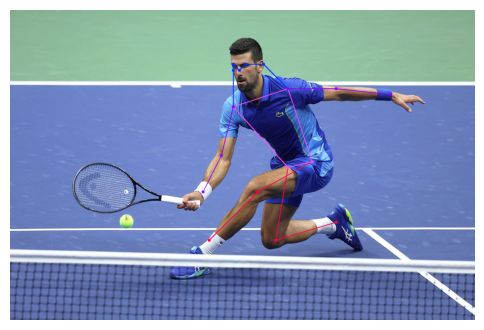

Visualisation et exosquelette tracé.


In [ ]:
# créer un fichier CSV avec
video_choice = to_csv("images") # video_choice est inutile dans le cas d'une image
dessiner_exosquelette("images", video_choice)

---

#### ***3.2 Sur une vidéo***

Ensuite, on applique le même procédé sur une vidéo.

---

In [ ]:
# Supprime les dossiers et fichiers existant
!rm -rf /content/resultats_poses

In [ ]:
!pip install moviepy

In [ ]:
#######################################
# UPLOAD VIDEO ET DECOUPAGE EN FRAMES #
#######################################

import cv2
import os, glob
from moviepy.editor import VideoFileClip

# --- Configuration ---
os.makedirs('/content/videos', exist_ok=True)
os.makedirs('/content/frames', exist_ok=True)


# On propose d’uploader
from google.colab import files
print("Sélectionne une vidéo locale à analyser :")
uploads = files.upload()

video_fps = 60
for name in uploads.keys():

    # transformation en GIF
    clip = VideoFileClip(name)

    video_width = clip.w
    video_fps = clip.fps
    video_duration = clip.duration

    new_name = f"{name[:-4]}.gif"

    gif = clip.subclip(0,video_duration).resize(width=video_width)
    gif.write_gif(f"{new_name}", fps=video_fps)
    gif.close()

    os.rename(new_name, f"/content/videos/{new_name}")

# Vérification
print("Vidéos prêtes :", glob.glob('/content/videos/*'))

frame_interval = 1  # 1 = toutes les frames

for path_vid in glob.glob('/content/videos/*'):
    name_vid = path_vid[16:]
    # Dossier où mettre les frames
    output_folder = '/content/frames/' + name_vid
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(path_vid)

    if not cap.isOpened():
        print("Erreur : Impossible d'ouvrir la vidéo.")
    else:
        frame_count = 0
        saved_count = 0

        print("Extraction en cours...")

        while True:
            ret, frame = cap.read()

            # Si ret est False, c'est la fin de la vidéo
            if not ret:
                break

            # Sauvegarde seulement si on respecte l'intervalle
            if frame_count % frame_interval == 0:
                # Nom du fichier avec 4 zéros (ex: frame_0001.jpg) pour bien trier
                filename = f"frame_{saved_count:04d}.jpg"
                save_path = os.path.join(output_folder, filename)

                cv2.imwrite(save_path, frame)
                saved_count += 1

            frame_count += 1

        cap.release()
        print(f"Terminé ! {saved_count} images extraites dans '{output_folder}'.")

Sélectionne une vidéo locale à analyser :


Saving alcaraz.mp4 to alcaraz.mp4
MoviePy - Building file alcaraz.gif with imageio.


Vidéos prêtes : ['/content/videos/alcaraz.mp4', '/content/videos/alcaraz.gif']
Extraction en cours...
Terminé ! 378 images extraites dans '/content/frames/alcaraz.mp4'.
Extraction en cours...
Terminé ! 378 images extraites dans '/content/frames/alcaraz.gif'.


In [ ]:
video_choice = to_csv("frames")
dessiner_exosquelette(f"frames/{video_choice}", video_choice)


alcaraz.mp4
alcaraz.gif
Quelle vidéo voulez-vous traiter ?alcaraz.gif
CSV écrit : /content/out/keypoints.csv


---

Lorsque nous avons appliqué ce procédé, on rassemble toutes les frames sur lesquelles nous avons relié les keypoints pour en faire une nouvelle vidéo :

---

In [ ]:
import cv2
import glob
import os

# --- Configuration ---
image_folder = '/content/resultats_poses_' + video_choice # Dossier contenant tes frames traitées
video_name = '/content/' + video_choice[:-4] + '_result.mp4' # Nom de la vidéo de sortie

cap = cv2.VideoCapture('/content/videos/' + video_choice)

# 1. Récupération et tri des images
# Le tri (sorted) est curcial pour que la vidéo soit dans le bon ordre.
# On cherche les .jpg et .png pour être sûr.
images = sorted(glob.glob(os.path.join(image_folder, '*.jpg')) +
                glob.glob(os.path.join(image_folder, '*.png')))

if not images:
    print(f"Erreur : Aucune image trouvée dans {image_folder}")
    exit()

# 2. Lecture de la première image pour déterminer la taille de la vidéo
# OpenCV a besoin de connaître la hauteur et la largeur AVANT de créer le fichier vidéo.
first_frame = cv2.imread(images[0])
height, width, layers = first_frame.shape
video_size = (width, height) # Note : OpenCV attend (largeur, hauteur)

print(f"Détection de la taille : {width}x{height}")
print(f"Création de la vidéo avec {len(images)} frames à {video_fps} FPS...")

# 3. Configuration du VideoWriter
# FourCC est un code de 4 lettres pour le codec vidéo.
# 'mp4v' fonctionne généralement bien pour les fichiers .mp4.
# Si ça ne marche pas, essayer 'avc1' (H.264) ou 'XVID' (pour un fichier .avi)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(video_name, fourcc, video_fps, video_size)

# 4. Boucle d'écriture
for img_path in images:
    # Lecture de l'image
    img = cv2.imread(img_path)

    # Vérification de sécurité (si une image est corrompue)
    if img is None:
        print(f"Attention : Impossible de lire {img_path}, frame ignorée.")
        continue

    # Ajout de l'image dans le flux vidéo
    out.write(img)

# 5. Finalisation
# Très important : cela ferme le fichier et finalise l'encodage.
out.release()
print(f"Vidéo terminée et sauvegardée sous : {video_name}")

Détection de la taille : 750x722
Création de la vidéo avec 378 frames à 60.0 FPS...
Vidéo terminée et sauvegardée sous : /content/alcaraz_result.mp4


In [ ]:
# On télécharge la vidéo finale

from google.colab import files
files.download(video_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ***4. Analyse des trajectoires***

Dans cette partie, nous essayons de quantifier la cinématique du mouvement observé dans la vidéo en exploitant les données brutes d'estimation de pose générées par le modèle.

Premièrement, pour chaque image de la séquence vidéo, nous récupérons les pixels/coordonnées (x,y) des articulations clés (keypoints). Nous nous concentrons ici sur le suivi d'un point d'intérêt majeur (ex: right_wrist), pour en étudier la dynamique. Nous utilisons le poignet droit, car c'est le plus pertinent dans le cadre d'une vidéo sur le tennis mais cette partie du corps est totalement modifiable.

Nous avons notamment calculé des métriques telles que la vitesse instantanée via un calcul de la distance euclidienne parcourue par le point clé entre deux frames consécutives. L'unité de mesure est le pixel/frame, correspondant au déplacement dans le référentiel de l'image.

Enfin, nous avons constaté que les modèles de détection comportent un léger bruit naturel (tremblements de détection), nous avons donc vu que l'on pouvait appliquer une moyenne mobile (rolling mean) sur une fenêtre glissante de 5 frames. Cela permet de filtrer les micro-variations parasites et de visualiser la fluidité réelle du geste humain.

---

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/out/keypoints.csv')

#On trie les lignes par nom d'image pour être sûr que c'est dans l'ordre chronologique
# (frame_0001, frame_0002, etc.) sinon le calcul de vitesse sera faux.
df = df.sort_values(by='image')

"""
Fonction qui permet de récupérer les coordonnées (x, y) d'une partie du corps à partir du dataframe.

@param body_part : Le point clé que l'on souhaite étudier.
@return x_positions, y_positions : Les coordonnées (x, y) du point clé.

"""
def get_body_part_xy(body_part):

  # On récupère les colonnes X et Y du point choisi
  x_positions = df[f'{body_part}_x']
  y_positions = df[f'{body_part}_y']

  return x_positions, y_positions



"""
Fonction qui permet de calculer le déplacement entre deux frames successives via la distance euclidienne.

@param body_part : Le point clé que l'on souhaite étudier.
@return distance_per_frame : La distance parcourue par le point clé entre deux frames successives.

"""
def body_part_step_distance(body_part):

  # On calcule la différence de position entre chaque image (dx et dy)
  dx = df[f'{body_part}_x'].diff()
  dy = df[f'{body_part}_y'].diff()

  # Pythgaore
  distance_per_frame = np.sqrt(dx**2 + dy**2)

  return distance_per_frame


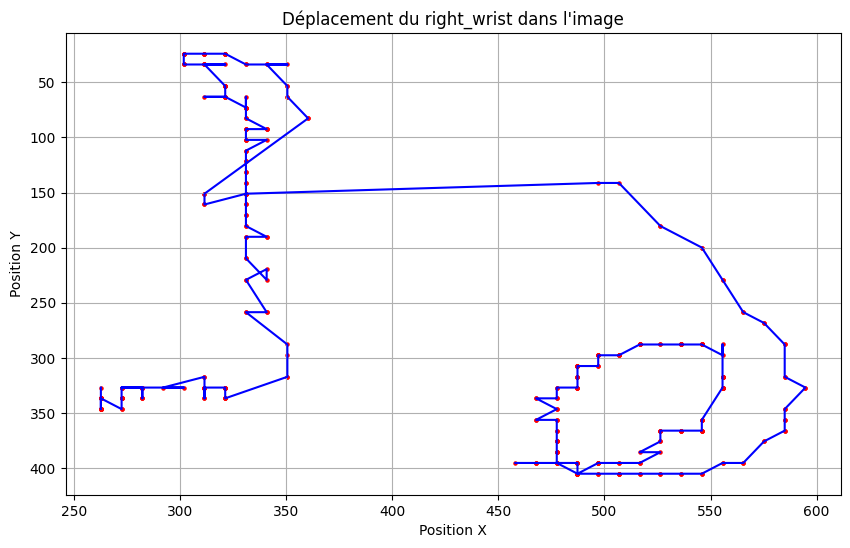

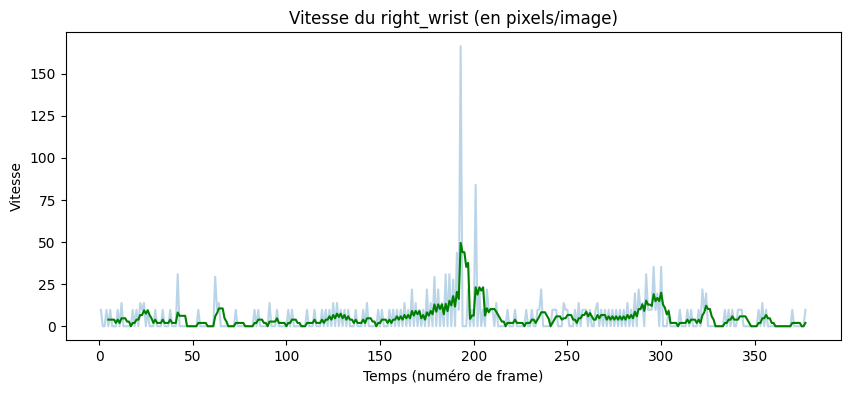

--- Résultats ---
Point analysé : right_wrist
Distance totale parcourue : 1970 pixels
Vitesse max atteinte : 166 pixels/frame
Vitesse moyenne : 5.23 pixels/frame


In [48]:

# --- GRAPHIQUE 1 : La trajectoire ---

# On peut modifier la partie du corps à étudier ici
body_part = 'right_wrist'

x_positions, y_positions = get_body_part_xy(body_part)

plt.figure(figsize=(10, 6))
plt.plot(x_positions, y_positions, label='Trajectoire', color='blue')
plt.scatter(x_positions, y_positions, s=5, color='red') # Ajoute des points rouges pour voir chaque frame

# On inverse l'axe Y car sur une image le (0,0) est en haut à gauche
plt.gca().invert_yaxis()

plt.title(f"Déplacement du {body_part} dans l'image")
plt.xlabel("Position X")
plt.ylabel("Position Y")
plt.grid()
plt.show()

# --- GRAPHIQUE 2 : La vitesse ---

distance_per_frame = body_part_step_distance(body_part)

# On lisse un peu la courbe (moyenne sur 5 images) pour que ce soit plus lisible
# car la détection tremble un peu parfois
smoothed_speed = distance_per_frame.rolling(window=5).mean()

plt.figure(figsize=(10, 4))
plt.plot(distance_per_frame, label='Vitesse brute', alpha=0.3)
plt.plot(smoothed_speed, label='Vitesse lissée', color='green')
plt.title(f"Vitesse du {body_part} (en pixels/image)")
plt.xlabel("Temps (numéro de frame)")
plt.ylabel("Vitesse")
plt.show()

# --- Quelques stats ---
dist_totale = distance_per_frame.sum()
vitesse_max = distance_per_frame.max()
vitesse_moy = distance_per_frame.mean()

print("--- Résultats ---")
print(f"Point analysé : {body_part}")
print(f"Distance totale parcourue : {int(dist_totale)} pixels")
print(f"Vitesse max atteinte : {int(vitesse_max)} pixels/frame")
print(f"Vitesse moyenne : {round(vitesse_moy, 2)} pixels/frame")




# **Interprétation :**

L'analyse des graphiques obtenus sur le point right_wrist (poignet droit) met en évidence la cinématique du coup de tennis :

- Analyse Temporelle (Vitesse) :

  Le graphique de vitesse montre une distinction nette entre deux phases. De la frame 0 à 170 environ, la vitesse est relativement faible et constante (autour de 5-10 px/frame), ce qui correspond à la phase de préparation ou d'attente du joueur.

  Autour de la frame 190, on observe un pic d'accélération majeur où la vitesse instantanée bondit jusqu'à 137 pixels/frame. Ce pic correspond au moment de l'impact ou de l'accélération du bras pour la frappe.

  La courbe lissée (en vert) confirme que ce pic n'est pas une erreur de mesure (bruit), mais bien un mouvement ample et continu.


- Analyse Spatiale (Trajectoire) :

  Le tracé (X, Y) montre une trajectoire complexe avec des boucles, caractéristique d'un mouvement de balancier ou d'un service au tennis, plutôt qu'un simple déplacement linéaire.


- Statistiques Globales :

  La vitesse moyenne est faible (4.84 px/frame) car elle prend en compte la longue phase d'attente.

  La distance totale parcourue de 1824 pixels témoigne de l'amplitude importante du geste technique que nous avons analysé.

---
## ***5. Prédiction de l'évolution du mouvement***

---

Nous avons choisi d'utiliser un réseau de neurones LSTM réalisé nous-mêmes afin de faire la prédiction.

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

df = pd.read_csv('/content/out/keypoints.csv')

# On ne garde que les coordonnées (on exclut 'score', 'image', 'instance_id')
coord_cols = [c for c in df.columns if c.endswith('_x') or c.endswith('_y')]
data = df[coord_cols].values # Forme (N_frames, 34) car 17 keypoints * 2

# Normalisation
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Création des fenêtres glissantes
def create_sequences(dataset, look_back=5):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i+look_back]) # Frames t à t+4
        y.append(dataset[i+look_back])   # Frame t+5 (cible)
    return np.array(X), np.array(y)

LOOK_BACK = 60
X, y = create_sequences(data_scaled, LOOK_BACK)

# Split Train/Test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Création et Entraînement du Modèle LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(128, activation='relu', return_sequences=True, input_shape=(LOOK_BACK, X.shape[2])))
model_lstm.add(LSTM(64, activation='relu', input_shape=(LOOK_BACK, X.shape[2])))
model_lstm.add(Dense(X.shape[2]))
model_lstm.compile(optimizer='adam', loss='mse')

print("Début de l'entraînement...")
model_lstm.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)
print("Entraînement terminé.")

def predict_next_frame_keypoints(last_5_frames_coords):
    """
    Entrée: Array numpy de shape (5, 34) avec les vraies coordonnées
    Sortie: Array numpy de shape (34,) avec les coordonnées prédites
    """
    # 1. Normaliser
    input_scaled = scaler.transform(last_5_frames_coords)
    # 2. Reshape pour le LSTM (1, 5, 34)
    input_reshaped = input_scaled.reshape(1, LOOK_BACK, data.shape[1])
    # 3. Prédire
    prediction_scaled = model_lstm.predict(input_reshaped, verbose=0)
    # 4. Dé-normaliser pour avoir des pixels
    prediction = scaler.inverse_transform(prediction_scaled)

    return prediction[0]

  super().__init__(**kwargs)



Début de l'entraînement...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.3750
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.1256
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0480
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0218
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0149
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0102
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0074
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0057
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0048
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0045
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0043
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0036
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0034
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0029
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 6

On peut ensuite générer un graphique qui affichera la trajectoire réelle et la trajectoire prédite afin d'analyser l'efficacité de la prédiction de l'IA.

Prédictions sur 318 fenêtres → 318 frames couvertes
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


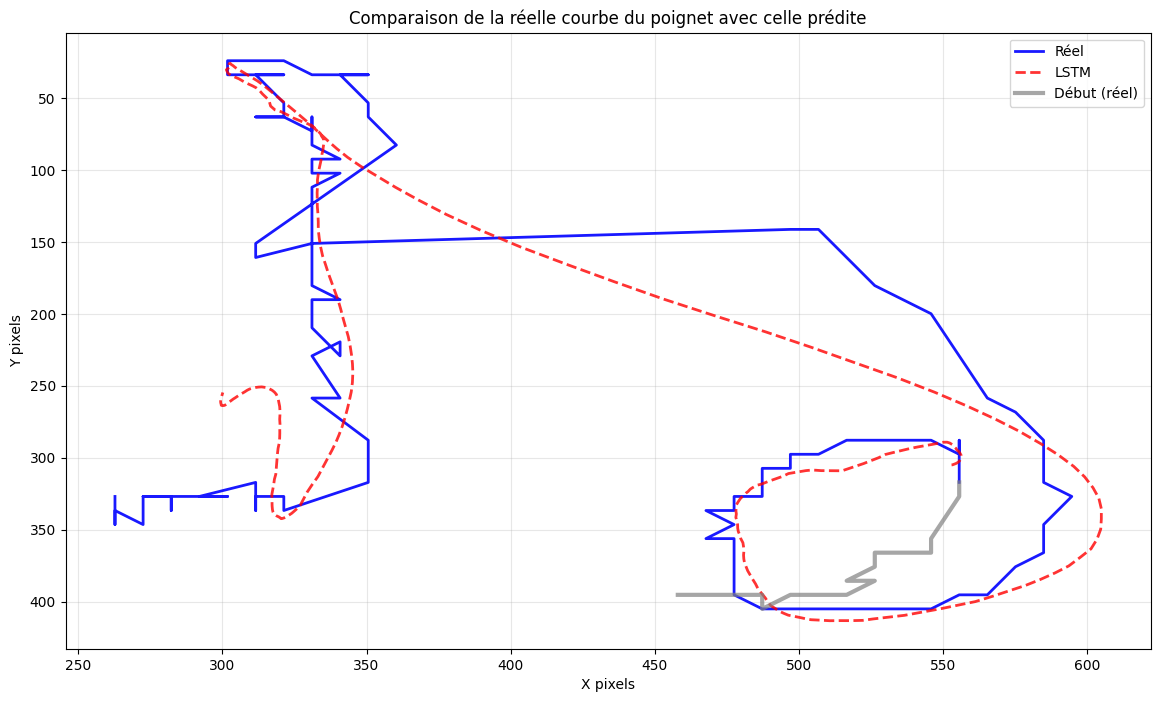

RMSE poignet COMPLET: 27.6px


In [57]:
import matplotlib.pyplot as plt
import numpy as np

# TOUTES les prédictions sur TOUS les inputs possibles
X_full, y_full = create_sequences(data_scaled, LOOK_BACK)
print(f"Prédictions sur {len(X_full)} fenêtres → {len(y_full)} frames couvertes")

predictions_full = model_lstm.predict(X_full, verbose=1)
all_predictions = scaler.inverse_transform(predictions_full)
all_reals_full = scaler.inverse_transform(y_full)

wrist_x_idx = coord_cols.index('right_wrist_x')
wrist_y_idx = coord_cols.index('right_wrist_y')

plt.figure(figsize=(14, 8))

# TOUT le mouvement (frames LOOK_BACK → fin)
frames_couvertes = all_reals_full[:, [wrist_x_idx, wrist_y_idx]]
frames_predites = all_predictions[:, [wrist_x_idx, wrist_y_idx]]

plt.plot(frames_couvertes[:, 0], frames_couvertes[:, 1],
         'b-', linewidth=2, label='Réel', alpha=0.9)
plt.plot(frames_predites[:, 0], frames_predites[:, 1],
         'r--', linewidth=2, label='LSTM', alpha=0.8)

# Début historique (gris)
plt.plot(data[:LOOK_BACK, wrist_x_idx], data[:LOOK_BACK, wrist_y_idx],
         'gray', linewidth=3, label='Début (réel)', alpha=0.7)

plt.gca().invert_yaxis()
plt.title(f"Comparaison de la réelle courbe du poignet avec celle prédite")
plt.xlabel("X pixels"); plt.ylabel("Y pixels")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

rmse = np.sqrt(np.mean((all_predictions[:, [wrist_x_idx, wrist_y_idx]] - all_reals_full[:, [wrist_x_idx, wrist_y_idx]])**2))
print(f"RMSE poignet COMPLET: {rmse:.1f}px")


Les résultats montrent que le modèle LSTM parvient à capturer la dynamique globale du mouvement, comme en témoigne la proximité entre la trajectoire prédite et la trajectoire réelle.
Toutefois, des écarts persistants subsistent, suggérant que le modèle peine à modéliser certaines dépendances temporelles fines et variations locales du mouvement. Ces limites peuvent
s’expliquer par par la quantité et la diversité restreintes des données utilisées. Le téléchargement et le traitement des vidéos étant lent, il était compliqué d'en télécharger plusieurs.

 De plus, les divers problèmes que nous avons rencontrés lors de l'installation d'un modèle IA plus performant nous
ont contraint à nous rapatrier sur un modèle moins efficace qui mettait du temps à effectuer le traitement d'une vidéo, même courte. Ces soucis d'ordre technique ont rendu difficile l'analyse sur une banque de données réduite.

---

*Rendu du groupe composé de :*
```
BABU Bastien
CLAUX Jérémy
PARODI Pierre
QASSEMYAR David
```